In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_excel('cleaned_data/Merged_Full_Data.xlsx')

In [3]:
import pandas as pd
pd.read_pickle("finall_mwrged_full_data.pickle").to_csv("finall_mwrged_full_data.csv")

In [3]:
data.columns

Index([                                 'Unnamed: 0',
                                         'Work code',
                                      'order number',
                                       'Repair date',
                                   'Machine names_x',
                                       'Main system',
                                      'Machine code',
                                        'sub system',
                                         'Repairman',
                                      'Type of work',
                             'سیستم برق و الکترونیک',
                                                1742,
                                'تعمیرات2.4 الی 2.6',
                                             'prise',
                                             'start',
                                            'finish',
                                'قیمت دستور کار مهر',
                                           'start-g',
                            

In [4]:
print(data.iloc[0])

Unnamed: 0                                               79030
Work code                                                76431
order number                                           1282754
Repair date                                         1403/08/15
Machine names_x                        سواری بیابانی مرتب موسو
                                                ...           
On time (minutes)                                       143332
Source_File                           performance_1403_08.xlsx
Mileage between failuers                            145094.684
On time (minutes) between failuers                      143332
Road_Profile_Cluster                                         2
Name: 0, Length: 98, dtype: object


In [5]:
data.head()

,Unnamed: 0,Work code,order number,Repair date,Machine names_x,Main system,Machine code,sub system,Repairman,Type of work,سیستم برق و الکترونیک,1742,تعمیرات2.4 الی 2.6,prise,start,finish,قیمت دستور کار مهر,start-g,finish-g,duration,year,month,year_month_greg,year_month_jalali,quarter,CompanyName,Unnamed: 1,Category,Res1,MobileNumber,UnitGroup,Unnamed: 6,RepairHourlyPrice,Id,Unnamed: 9,Status,UnitName,LastWorkValue,Unnamed: 13,DriverName,GPS Code_perf,Section,Unnamed: 17,VINNumber,MotorNumber,DAMNumber,BodyNumber,PlakNumber_perf,Unnamed: 23,Unnamed: 24,CarColour,BuildDate,EstateNo,Unnamed: 29,Unnamed: 30,CarType,CarGroup_perf,Machine names_y,Total Absolute Road Length (km),% of Main Roads (Arterial Roads),% of Freeways (Motorways),% of Highways (Expressways),% of Minor Roads (Secondary Roads),% of Rural Roads,% of Transit Roads,% of Tunnel Length,% of Bridge Length,Road Length by Region,% of Road in Plains (Flat Terrain),% of Length in Mountainous Terrain,Length of Road in Rolling Terrain (Hilly)%,Weather Type,Road Length at Altitude < 500,% of Road Length at Altitude 500 to 1000,% of Road Length at Altitude 1000 to 1500,% of Road Length at Altitude 1500 to 2000,% of Road Length at Altitude 2000 to 2500,% of Road Length at Altitude 2500 to [3000],% of Road Length at Altitude > [3000],Total Route Length based on Elevation Level,Saturation Flow Adjustment Factors,UnitGroup_road,rows,UnitGroup_perform,Category-perforn,Machinenames-perform,PlakNumber_repair,CarGroup_repair,GPS Code_repair,Travel time,Mileage (KM),Average speed,Maximum speed,On time (minutes),Source_File,Mileage between failuers,On time (minutes) between failuers,Road_Profile_Cluster
0,79030,76431,1282754,1403/08/15,سواری بیابانی مرتب موسو,متفرقه,01-07-0154,--,*,جابجا کردن,-,-,تعمیرات8.1 الی 10.1,60000000.0,1403/08/22,1403/08/22,آبان - قیمت,2024-11-12,2024-11-12,0,2024,11,2024-11,1403-08,3,مرتب,NaN,گشت راهداری,NaN,09146473620,استان آذربایجان شرقی,NaN,0,11578,NaN,در تعمیر,نقلیه استان آذربایجان شرقی,819,NaN,ابراهیم محمدی_,26002235,اداره کل,NaN,IRCE833E00V354349,2010646,26-1-5,19S3T354349,ايران15-122الف11,NaN,NaN,نوکمدادی,1383,662,NaN,NaN,سواری بیابانی,سبک,سواری بیابانی مرتب موسو,13061,0.073884,0.017763,0.047929,0.103821,0.748718,0.08667,0.000674,0.000129,5449.589083,0.230325,0.74935,0.020325,سردسیر,0.068211,0.069347,0.445443,0.408689,0.008311,0.0,0.0,5449.589083,1.115098,استان آذربایجان شرقی,97,آذربایجان شرقی,_اداره کل,سواری بیابانی مرتب موسو,ايران15-122الف11,سبک,26002235,0,145094.684,57.50,185.0,143332,performance_1403_08.xlsx,145094.684,143332,2
1,89637,87961,1276036,1403/07/30,سواری بیابانی مرتب موسو,انتقال قدرت,01-07-0154,گیربکس,*,رفع عیب,-,-,تعمیرات 6.31 الی8.1,382700000.0,1403/08/03,1403/08/03,آبان - قیمت,2024-10-24,2024-10-24,0,2024,10,2024-10,1403-08,3,مرتب,NaN,گشت راهداری,NaN,09146473620,استان آذربایجان شرقی,NaN,0,11578,NaN,در تعمیر,نقلیه استان آذربایجان شرقی,819,NaN,ابراهیم محمدی_,26002235,اداره کل,NaN,IRCE833E00V354349,2010646,26-1-5,19S3T354349,ايران15-122الف11,NaN,NaN,نوکمدادی,1383,662,NaN,NaN,سواری بیابانی,سبک,سواری بیابانی مرتب موسو,13061,0.073884,0.017763,0.047929,0.103821,0.748718,0.08667,0.000674,0.000129,5449.589083,0.230325,0.74935,0.020325,سردسیر,0.068211,0.069347,0.445443,0.408689,0.008311,0.0,0.0,5449.589083,1.115098,استان آذربایجان شرقی,97,آذربایجان شرقی,_اداره کل,سواری بیابانی مرتب موسو,ايران15-122الف11,سبک,26002235,0,145094.684,57.50,185.0,143332,performance_1403_08.xlsx,0.000,0,2
2,43451,53439,1393964,1403/12/25,سواری بیابانی مرتب موسو,اتاق راننده,01-07-0154,کلیدها,*,ساخت,-,-,تعمیرات12.1 الی 2.2,49450000.0,1403/12/25,1404/02/02,اسفند-قیمت,2025-03-15,2025-04-22,38,2025,3,2025-03,1403-12,4,مرتب,NaN,گشت راهداری,NaN,09146473620,استان آذربایجان شرقی,NaN,0,11578,NaN,در تعمیر,نقلیه استان آذربایجان شرقی,819,NaN,ابراهیم محمدی_,26002235,اداره کل,NaN,IRCE833E00V354349,2010646,26-1-5,19S3T354349,ايران15-122الف11,NaN,NaN,نوکمدادی,1383,662,NaN,NaN,سواری بیابانی,سبک,سواری بیابانی مرتب موسو,13061,0.073884,0.017763,0.047929,0.103821,0.748718,0.08667,0.000674

In [6]:
initial_features = [
    # 'Repair date', 
    'Machine names_x',
    'Type of work',
    # 'year_month_jalali',
    'quarter',
    'CompanyName',
    'Category',
    'Weather Type',
    'Section',
    'BuildDate',
    'CarType',
    'Road_Profile_Cluster',
    'Average speed',
    'Maximum speed',
    'Travel time',
    'Repairman',
    'Main system',
    # 'UnitName',
    'CarGroup_perf',
    'Road_Profile_Cluster'
]

location_features = [
    'Total Absolute Road Length (km)',
    '% of Main Roads (Arterial Roads)',
    '% of Freeways (Motorways)',
    '% of Highways (Expressways)',
    '% of Minor Roads (Secondary Roads)',
            '% of Rural Roads',
        '% of Transit Roads',
        '% of Tunnel Length',
        '% of Bridge Length',
        'Road Length by Region',
    '% of Road in Plains (Flat Terrain)',
    '% of Length in Mountainous Terrain',
    'Length of Road in Rolling Terrain (Hilly)%',
                'Weather Type',
    'Road Length at Altitude < 500',
    '% of Road Length at Altitude 500 to 1000',
    '% of Road Length at Altitude 1000 to 1500',
    '% of Road Length at Altitude 1500 to 2000',
    '% of Road Length at Altitude 2000 to 2500',
    '% of Road Length at Altitude 2500 to [3000]',
    '% of Road Length at Altitude > [3000]',
    'Total Route Length based on Elevation Level',
    'Saturation Flow Adjustment Factors',
            'UnitGroup_road',

]

features = initial_features

Targets = [
    'prise',
    'duration'
    'Main system',
    'Mileage between failuers'
]

In [7]:
data[features].tail()

,Machine names_x,Type of work,quarter,CompanyName,Category,Weather Type,Section,BuildDate,CarType,Road_Profile_Cluster,Average speed,Maximum speed,Travel time,Repairman,Main system,CarGroup_perf,Road_Profile_Cluster
101753,لودر هپکو L90,نصب,1,هپکو,عملیات راهداری,گرم و مرطوب,NaN,1360,لودر,4,4.92,119.0,0,ابراهیم جهانگیرلو ت,سیستم برق والکترونیک,سنگین,4
101754,لودر هپکو L90,تعمیر,1,هپکو,عملیات راهداری,گرم و مرطوب,NaN,1360,لودر,4,4.92,119.0,0,ابراهیم جهانگیرلو ت,سیستم برق والکترونیک,سنگین,4
101755,لودر هپکو L90,نصب,2,هپکو,عملیات راهداری,گرم و مرطوب,NaN,1360,لودر,4,4.82,198.0,0,غلامعباس گنبدی فراشبند,اتاق راننده,سنگین,4
101756,بیل مکانیکی هپکو 912,باز و بست و تعمیر,3,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,1,31.30,111.0,0,حسینی,سیستم برق والکترونیک,سنگین,1
101757,بیل مکانیکی هپکو 912,باز و بست و تعمیر,3,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,1,31.30,111.0,0,حسینی,سیستم برق والکترونیک,سنگین,1


### prise

In [8]:
data['prise_category'] = pd.qcut(data['prise'], q=3, labels=[0, 1, 2])

In [10]:
from sklearn.preprocessing import OrdinalEncoder
categorlal_features = ['Machine names_x', 
                       'Type of work', 
                       'CompanyName', 'Category', 
                       'Weather Type', 'Section', 
                       'CarType', 'Main system', 
                       'UnitName', 'CarGroup_perf', 'Repairman']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Transform the data
data[categorlal_features] = encoder.fit_transform(data[categorlal_features].astype(str))

In [11]:
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = data[features]
y = data['prise_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Validation Metrics ---
Accuracy Score: 78.99%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      6791
           1       0.75      0.74      0.74      6788
           2       0.82      0.86      0.84      6773

    accuracy                           0.79     20352
   macro avg       0.79      0.79      0.79     20352
weighted avg       0.79      0.79      0.79     20352



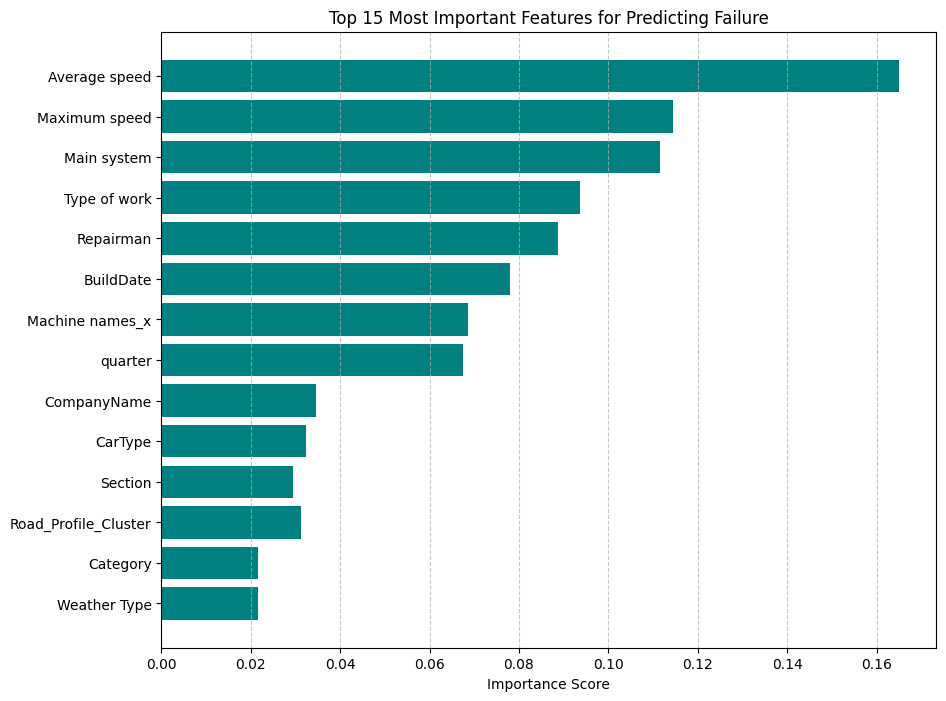

            Feature  Importance
10    Average speed    0.165105
11    Maximum speed    0.114523
14      Main system    0.111615
1      Type of work    0.093574
13        Repairman    0.088806
7         BuildDate    0.078090
0   Machine names_x    0.068568
2           quarter    0.067398
3       CompanyName    0.034591
8           CarType    0.032294


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pull the importance from the model
importances = model.feature_importances_

# 2. Match them with the column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.title('Top 15 Most Important Features for Predicting Failure')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df.head(10))

### duration

In [13]:
df = data[data['duration'] > 0]

In [14]:
df['duration_category'] = pd.qcut(df['duration'], q=5, labels=[0, 1, 2, 3, 4])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = df[features]
y = df['duration_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

C:\Users\AsreRayaneh\AppData\Local\Temp\ipykernel_8976\2395450042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_category'] = pd.qcut(df['duration'], q=5, labels=[0, 1, 2, 3, 4])


--- Validation Metrics ---
Accuracy Score: 82.06%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1925
           1       0.79      0.80      0.79      1938
           2       0.81      0.76      0.79      1779
           3       0.81      0.81      0.81      1883
           4       0.84      0.86      0.85      1817

    accuracy                           0.82      9342
   macro avg       0.82      0.82      0.82      9342
weighted avg       0.82      0.82      0.82      9342



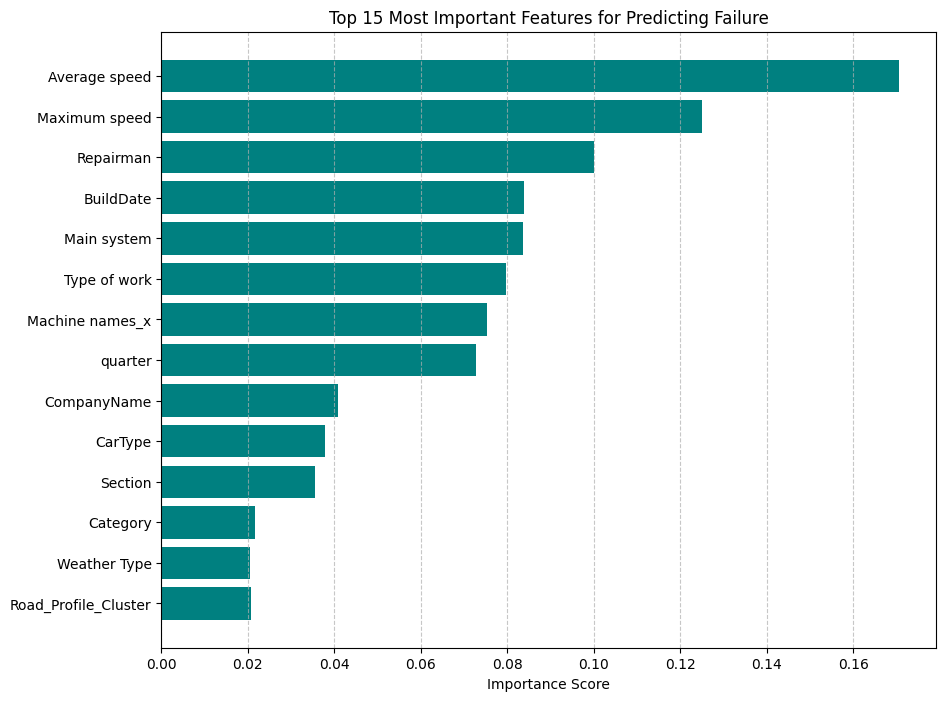

            Feature  Importance
10    Average speed    0.170658
11    Maximum speed    0.124996
13        Repairman    0.100020
7         BuildDate    0.083945
14      Main system    0.083705
1      Type of work    0.079597
0   Machine names_x    0.075299
2           quarter    0.072794
3       CompanyName    0.040906
8           CarType    0.037738


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pull the importance from the model
importances = model.feature_importances_

# 2. Match them with the column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.title('Top 15 Most Important Features for Predicting Failure')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df.head(10))